In [1]:
import zarr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import sys

sys.path.append(os.path.abspath(".."))
from src import get_params as gp

plt.style.use('../../my_style.mplstyle')
params = gp.get_params('/Volumes/data/Sasaki/backup_git/MTCargoSim/data/MTC/P0.5_A0.5/seed1.zarr')

path = r"/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5/seed*.zarr"

RDFs = []

for seed in glob.glob(path):
    RDF_path = os.path.join(seed, 'RDF.zarr')
    RDF_zarr = zarr.open(RDF_path, mode = 'r')
    RDF=RDF_zarr[1,:]

    RDFs.append(RDF)

bin = RDF_zarr[0,:]

RDFs_array = np.array(RDFs)

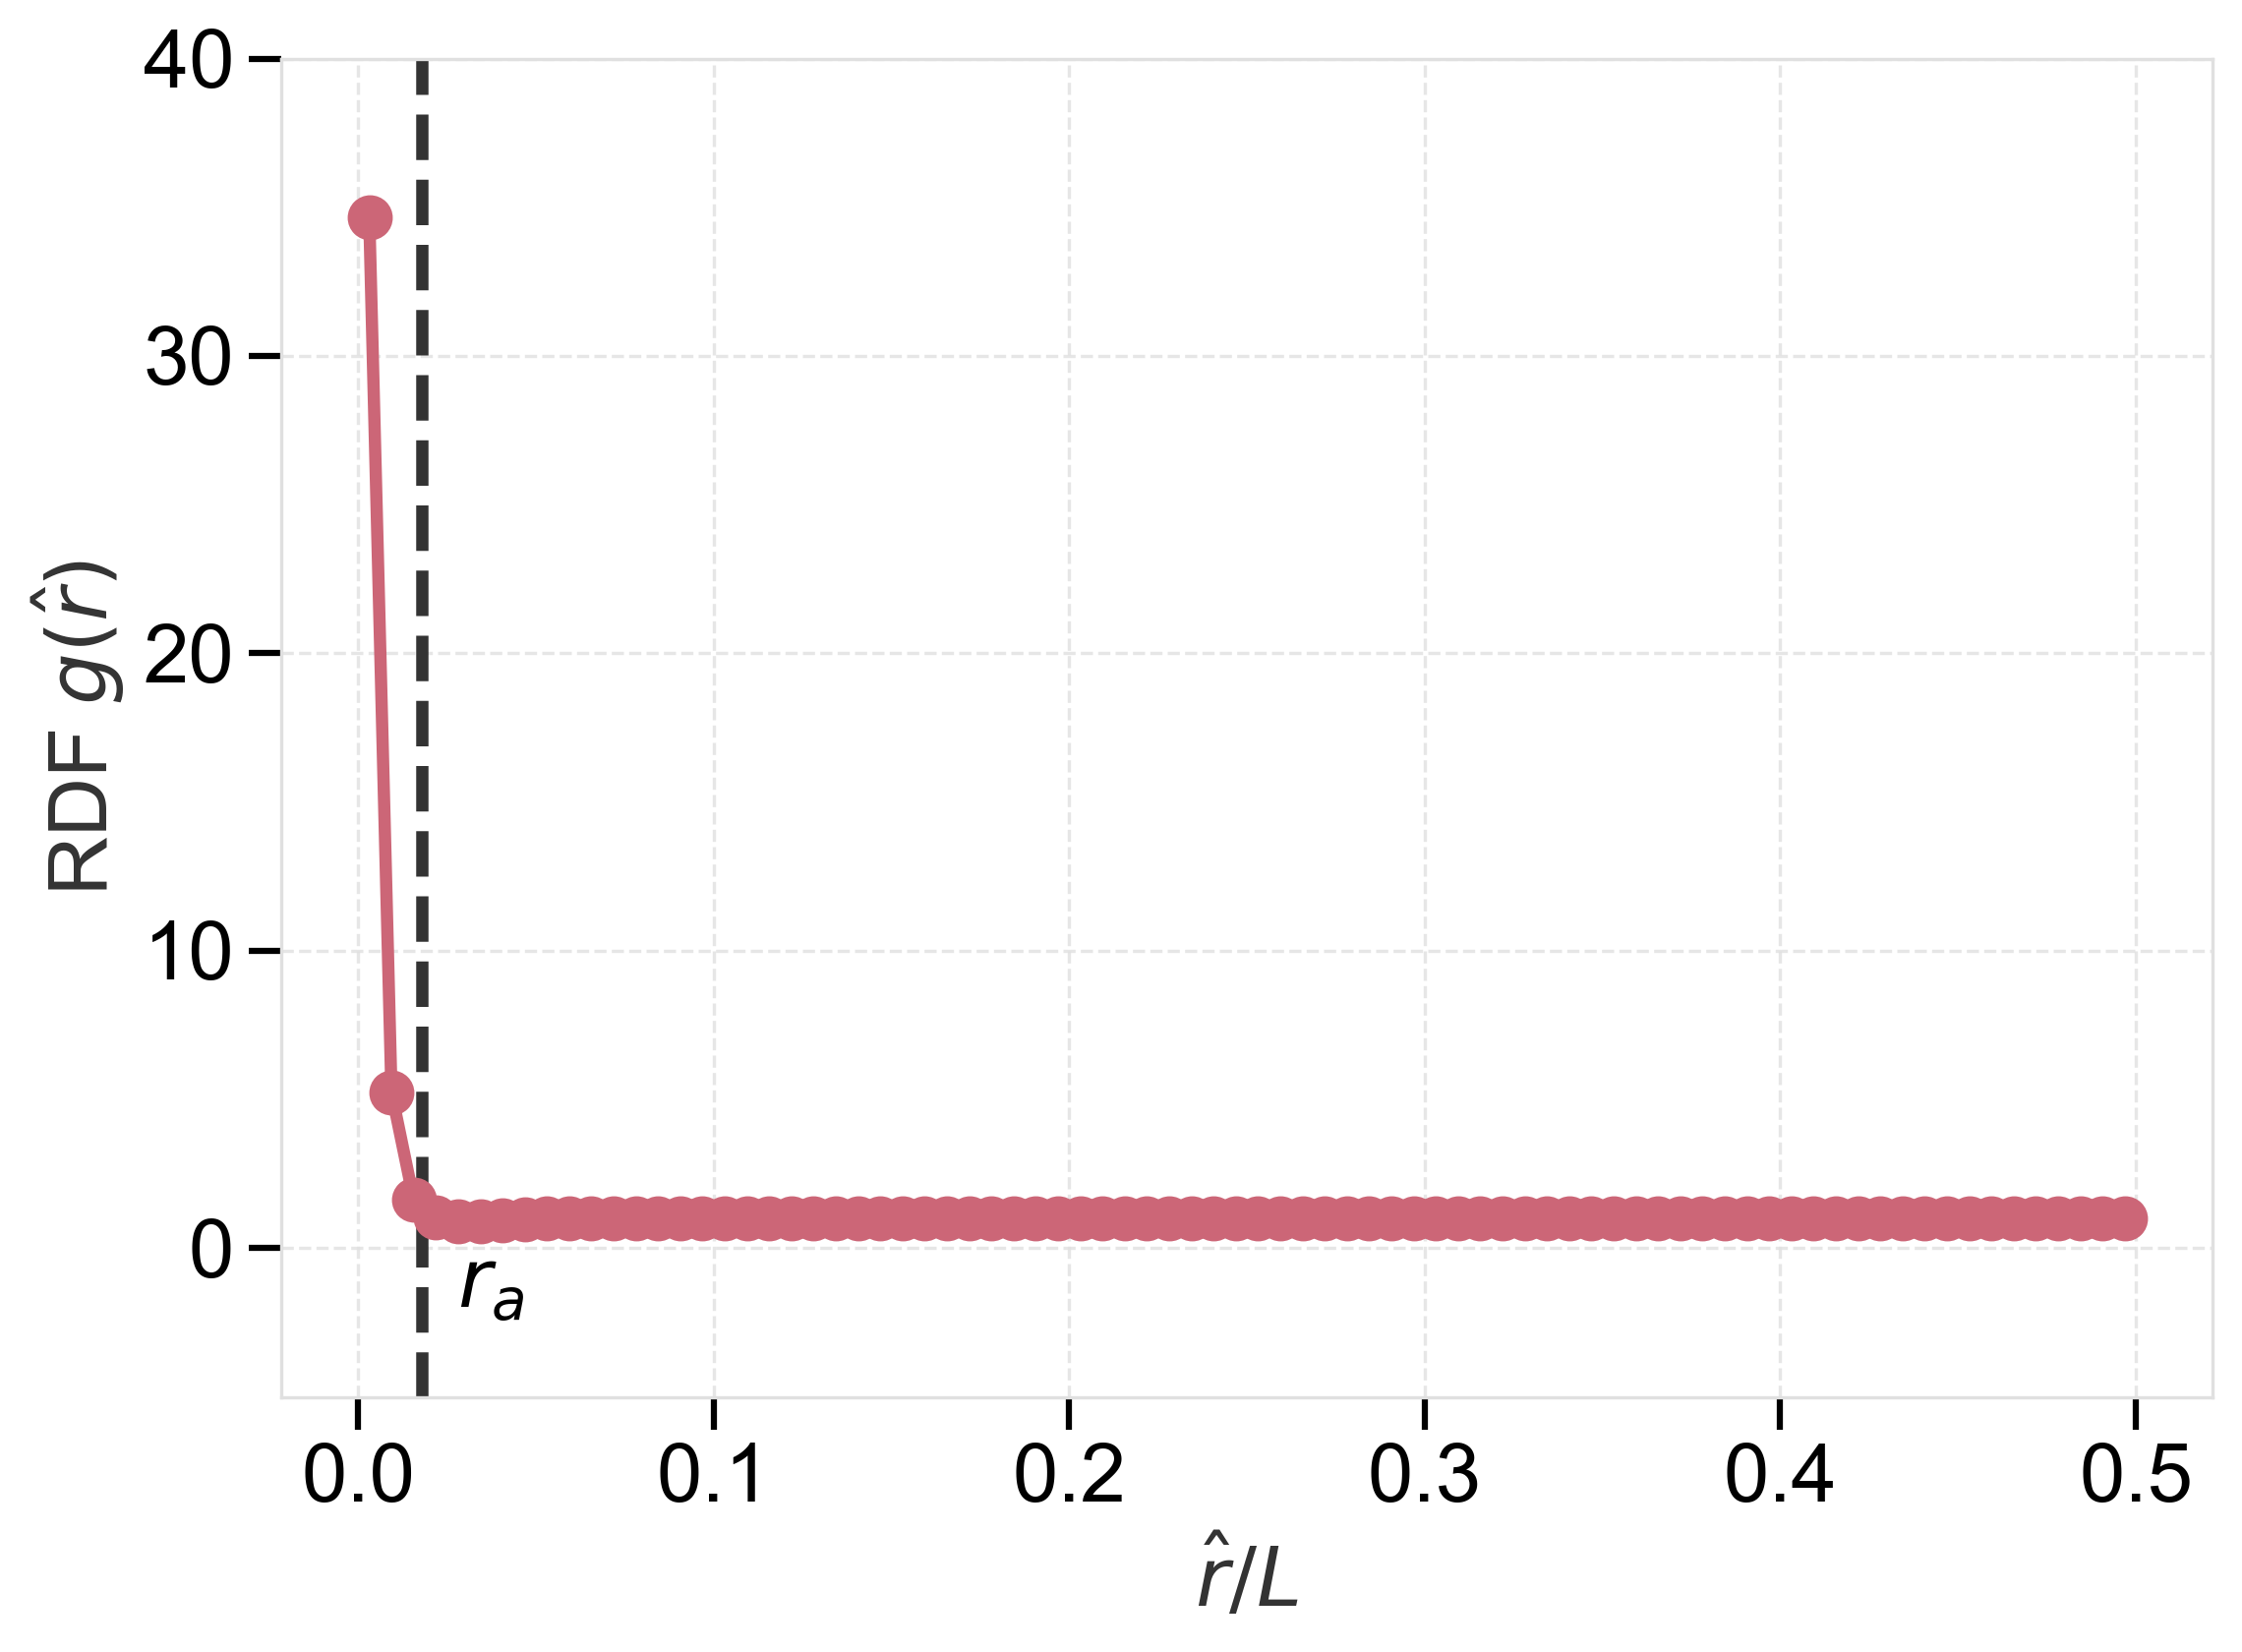

In [2]:
fig, ax = plt.subplots()

r_a = params['r_a']
L = params['box_size']
ax.vlines(r_a/L, -5, 40, colors='#333333', linestyles='--')
ax.text(r_a/L+0.01, -2, '$r_a$')

mean = np.mean(RDFs_array, axis = 0)
std = np.std(RDFs_array, axis = 0)

ax.plot(bin/L, mean, marker = 'o')

ax.set(
    xlabel='$\\hat{r}/L$',
    ylabel='RDF $g(\\hat{r})$',
    ylim=(-5, 40)
)

cd=os.getcwd()

fig.savefig(f"{cd}/figure/RDF.png", bbox_inches='tight')
fig.savefig(f"{cd}/figure/RDF.pdf", bbox_inches='tight')

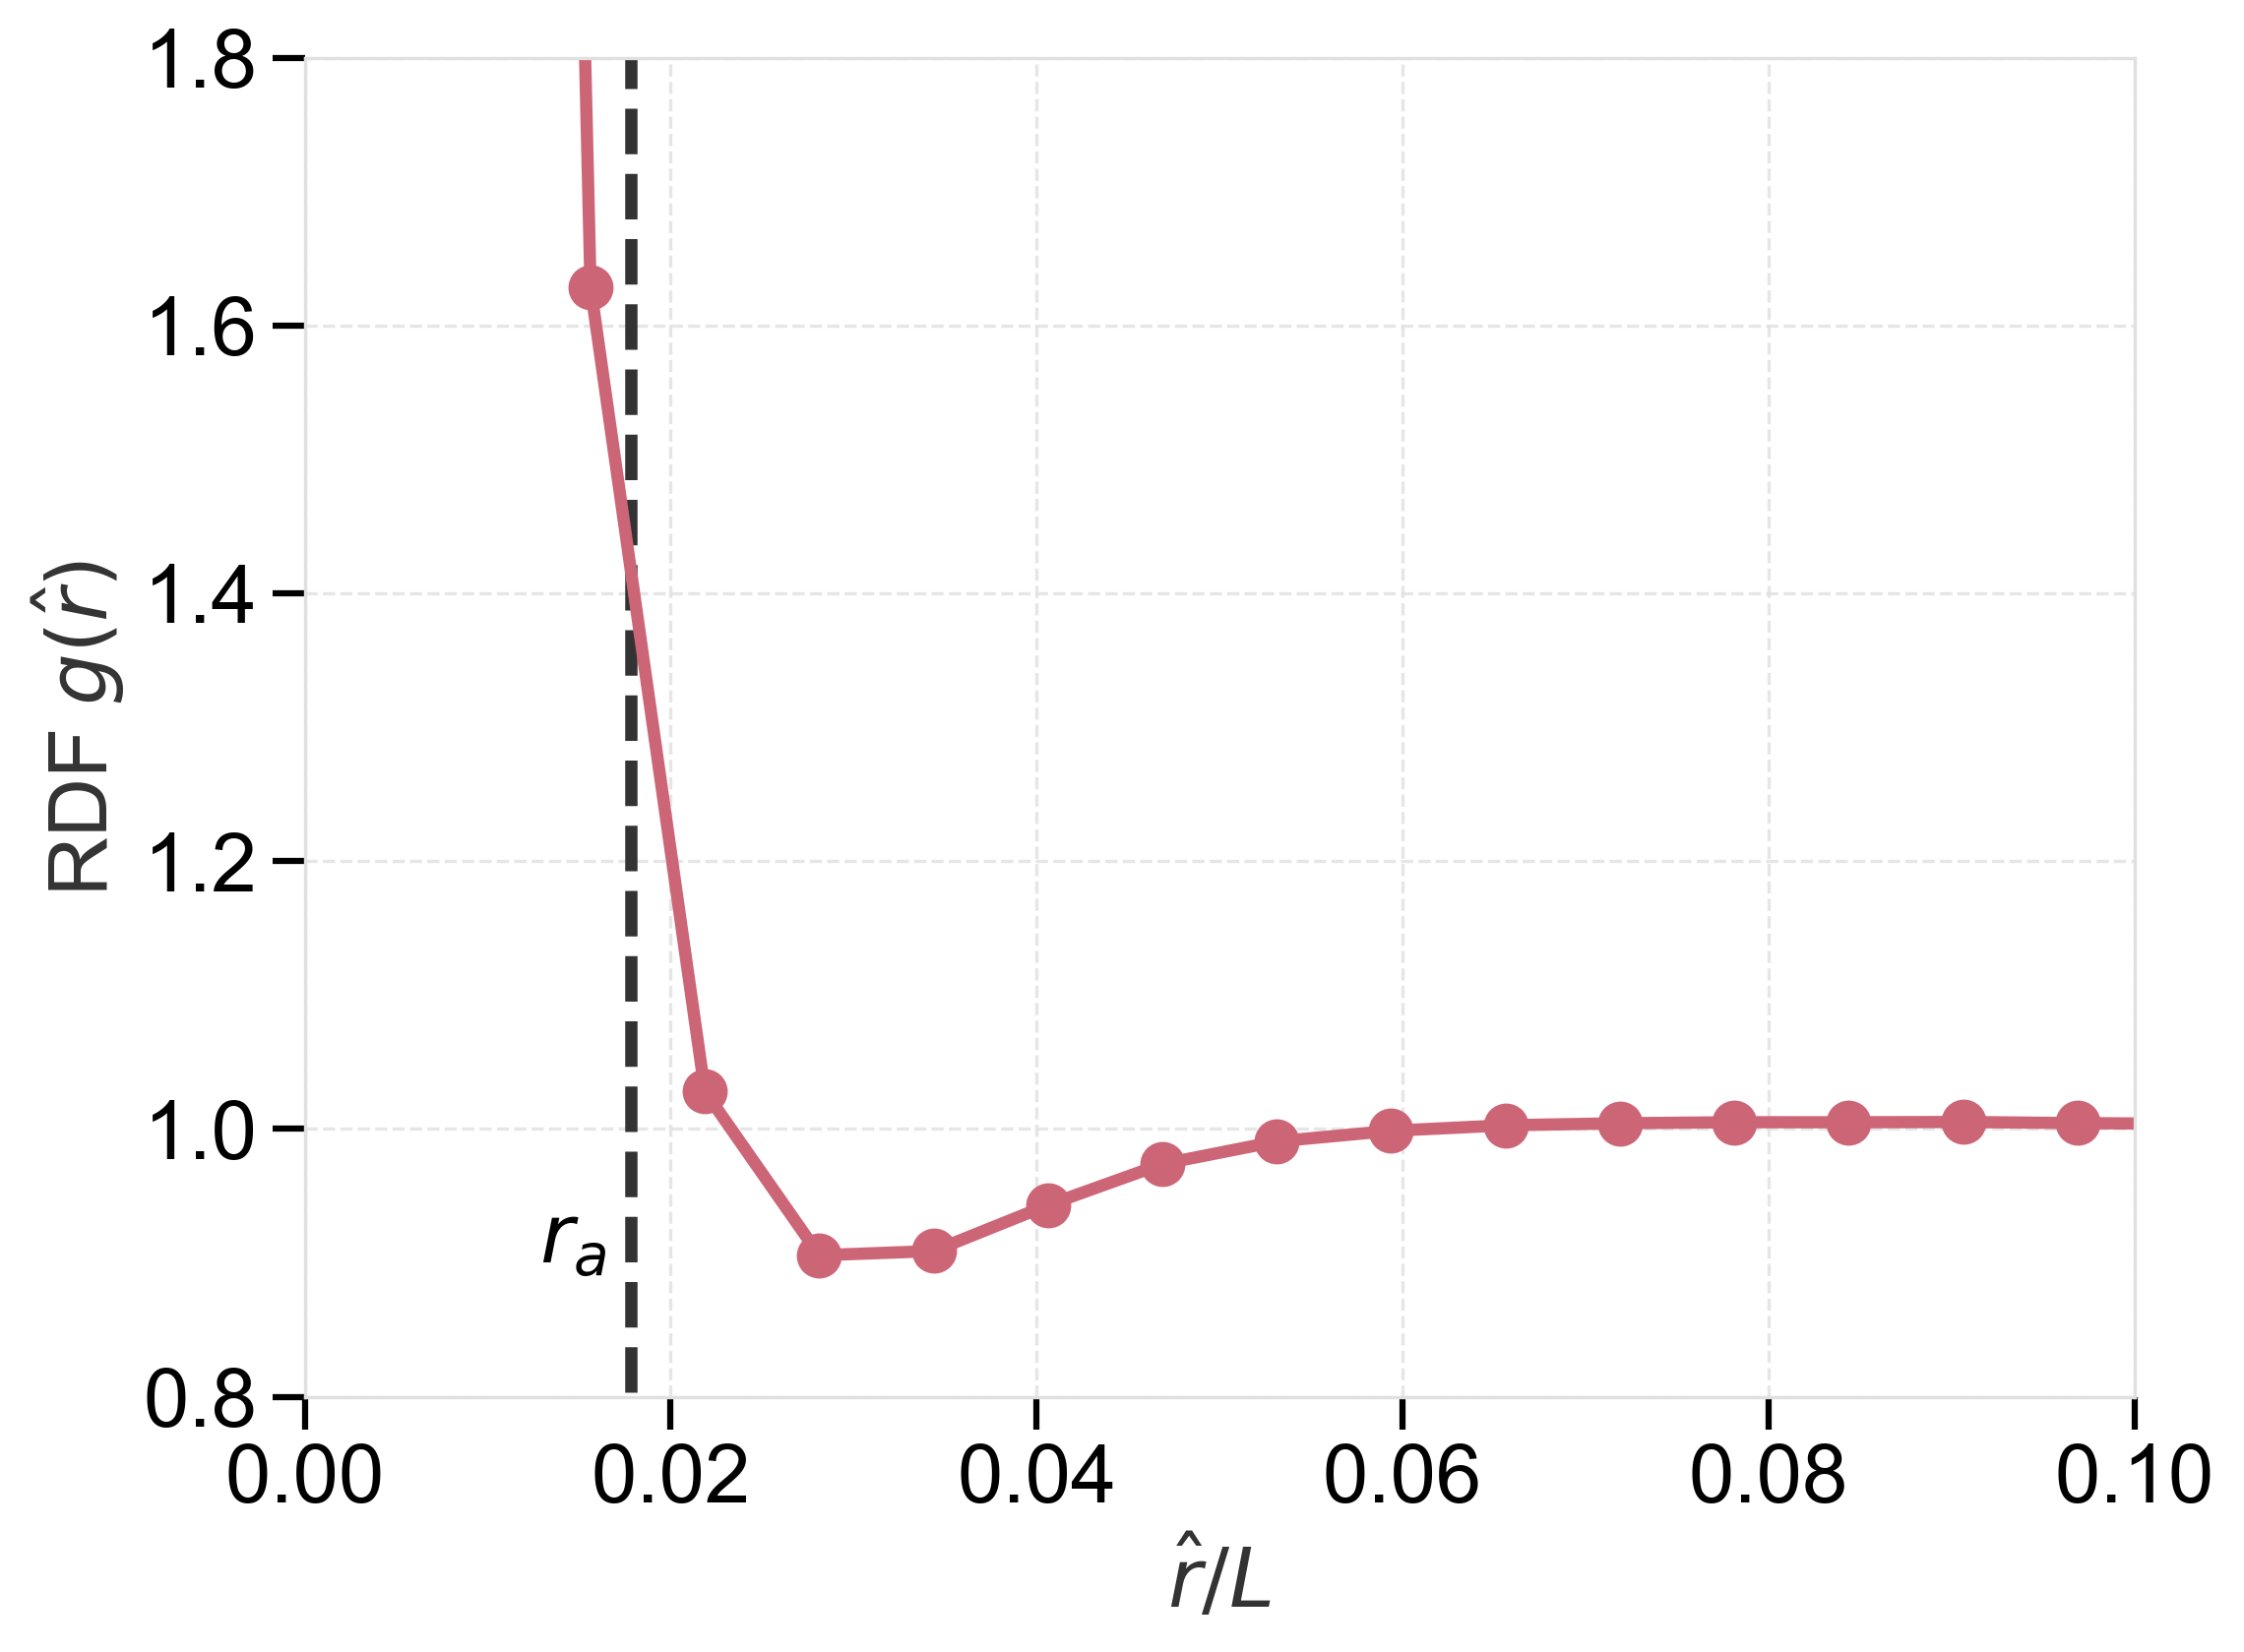

In [3]:
fig, ax = plt.subplots()

r_a = params['r_a']
L = params['box_size']
ax.vlines(r_a/L, -5, 40, colors='#333333', linestyles='--')
ax.text(r_a/L-0.005, 0.9, '$r_a$')

mean = np.mean(RDFs_array, axis = 0)
std = np.std(RDFs_array, axis = 0)

ax.plot(bin/L, mean, marker = 'o')



ax.set(
    xlabel='$\\hat{r}/L$',
    ylabel='RDF $g(\\hat{r})$',
    xlim=(0.0, 0.1),
    ylim=(0.8, 1.8)
)

cd=os.getcwd()

fig.savefig(f"{cd}/figure/RDF_zoom.png", bbox_inches='tight')
fig.savefig(f"{cd}/figure/RDF_zoom.pdf", bbox_inches='tight')